In [20]:
# two_softmax_diff_nnx.py
# Flax nnx 0.11.0
from __future__ import annotations

import jax, jax.numpy as jnp
from flax import nnx
import numpy as np

import matplotlib.pyplot as plt
import optax
from tqdm import tqdm
from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle

jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

In [21]:
# =========================
# Nodes & utilities
# =========================

def cheb_lobatto_nodes(M: int) -> jnp.ndarray:
    """M Chebyshev-Lobatto nodes on [-1,1], j=0..M-1."""
    j = jnp.arange(M, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / (M - 1))

def cheb2_weights(M: int) -> jnp.ndarray:
    # M >= 2
    j = jnp.arange(M, dtype=DTYPE)
    w = (-1.0) ** j
    w = w.at[0].mul(0.5)
    w = w.at[-1].mul(0.5)      # keeps the correct sign automatically
    return w

def cheb2_weights_abs(M: int) -> jnp.ndarray:
    return jnp.abs(cheb2_weights(M))

def cheb_lobatto_weight_signs(M: int) -> jnp.ndarray:
    # w_j ∝ (-1)^j with endpoints |w_0|=|w_{M-1}|=1/2; signs are just (-1)^j.
    j = jnp.arange(M, dtype=jnp.int32)
    return jnp.where((j & 1) == 0, DTYPE(1.0), DTYPE(-1.0))

def uniform_nodes(M: int) -> jnp.ndarray:
    return jnp.linspace(-1.0, 1.0, M, dtype=DTYPE)

def min_separation(xs: jnp.ndarray) -> DTYPE:
    """δ = min_{i≠j} |x_i - x_j|."""
    xs = xs.reshape(-1, 1)
    D = jnp.abs(xs - xs.T)
    D = D + jnp.eye(xs.shape[0], dtype=DTYPE) * 1e9
    return jnp.min(D)

In [22]:
# =========================
# Exact Gaussian logits
# =========================
def fixed_gaussian_logits(xs: jnp.ndarray, epsilon: DTYPE, a: jnp.ndarray | None = None):
    """
    Return W, b such that logits_j(x) = W[j] * x + b[j]
    corresponds to log a_j - (x - x_j)^2 / (2 ε^2), *up to*
    the -x^2/(2 ε^2) constant (cancels in softmax).

    The a's are optional, and correspond to the chebyshev weights in the second barycentric formula. 
    """
    xs = jnp.asarray(xs, dtype=DTYPE)
    inv_var = DTYPE(1.0) / (epsilon ** 2)
    W = xs * inv_var                                    # shape [M]
    b = -0.5 * (xs ** 2) * inv_var                      # shape [M]
    if a is not None:
        a = jnp.asarray(a, dtype=DTYPE)
        b = b + jnp.log(jnp.abs(a))
    return W, b

In [23]:
# =========================
# Fixed-logit softmax-Gaussian "MLP"
# =========================
class FixedGaussianSoftmax(nnx.Module):
    W: nnx.Param
    b: nnx.Param
    y: nnx.Param

    def __init__(
        self,
        xs: jnp.ndarray,
        ys: jnp.ndarray,
        epsilon: DTYPE,
        a: jnp.ndarray | None = None,
        *,
        gauss_init: bool = True,
        rng_seed: float = 0,
    ):  
        nnx_rng = nnx.Rngs(rng_seed)
        jax_key = jax.random.key(rng_seed)
        xs = jnp.asarray(xs, dtype=DTYPE)
        ys = jnp.asarray(ys, dtype=DTYPE)
        M = xs.shape[0]


        if gauss_init:
            W, b = fixed_gaussian_logits(xs, epsilon, a)
            self.W = nnx.Param(W)                       # [M]
            self.b = nnx.Param(b)                       # [M]
        else:
            # He (Kaiming) normal for scalar input: fan_in = 1
            he = nnx.initializers.he_normal()
            self.W = nnx.Param(jax.random.normal(jax_key, (M,), dtype=DTYPE) * 2/1.0)
            self.b = nnx.Param(jnp.zeros((M,), dtype=DTYPE))

        # mixture targets
        self.y = nnx.Param(ys)                          # [M]

    def alpha_f(self, x: jnp.ndarray):
        logits = self.W[None, ...] * x[..., None] + self.b[None, ...]
        return jax.nn.softmax(logits, axis=-1)

    def __call__(self, x: jnp.ndarray):
        logits = self.W[None, ...] * x[..., None] + self.b[None, ...]
        alpha = jax.nn.softmax(logits, axis=-1)
        y_hat = jnp.einsum('...m,m->...', alpha, self.y)
        return y_hat


In [24]:
class MLP(nnx.Module):

    def __init__(self, layer_sizes: list[int], activation,  *, rngs: nnx.Rngs = nnx.Rngs(0)):
        layers = []
        for i in range(len(layer_sizes) - 2):
            layer = nnx.Linear(layer_sizes[i], layer_sizes[i + 1], rngs=rngs)
            layers.append(layer)
            layers.append(activation)
        layers.append(nnx.Linear(layer_sizes[-2], layer_sizes[-1], rngs=rngs))
        #print(layers)
        print(len(layers))
        self.layers = nnx.Sequential(*layers)
        

    def __call__(self, x: jnp.ndarray):
        x = self.layers(x)
        return x

In [25]:
# -------------------------
# Two-head difference model
# -------------------------
class TwoSoftmaxDiff(nnx.Module):
    f: FixedGaussianSoftmax
    g: FixedGaussianSoftmax
    xs: jnp.ndarray
    ys: nnx.Param
    tol_node: DTYPE

    def __init__(self,
                 xs: jnp.ndarray,
                 ys: jnp.ndarray,
                 eps_f: float,
                 eps_g: float | None = None,
                 a_mag_f: jnp.ndarray | None = None,
                 a_mag_g: jnp.ndarray | None = None,
                 tol_node: float = 1e-14,
                 *,
                 softmax_first: bool = False,
                 gauss_init: bool = True,
                 rng_seed : float = 0,):
        xs = jnp.asarray(xs, dtype=DTYPE)
        ys = jnp.asarray(ys, dtype=DTYPE)
        eps_g = eps_f if eps_g is None else eps_g
        self.f = FixedGaussianSoftmax(xs, ys, epsilon=eps_f, a=a_mag_f, gauss_init=gauss_init, rng_seed=rng_seed)
        self.g = FixedGaussianSoftmax(xs, ys, epsilon=eps_g, a=a_mag_g, gauss_init=gauss_init, rng_seed=rng_seed)
        self.xs = xs
        self.ys = nnx.Param(ys)
        self.softmax_first = softmax_first

    def alpha_f(self, x: jnp.ndarray):
        logits_f = self.f.W[None, ...] * x[..., None] + self.f.b[None, ...]
        return jax.nn.softmax(logits_f, axis=-1)

    def __call__(self, x: jnp.ndarray):
        """
        Returns:
          y_hat: [...],
          alpha_f: [..., M], alpha_g: [..., M]
        """
        # α_f, α_g
        if self.softmax_first:
            alpha_f = self.f.alpha_f(x)
            alpha_g = self.g.alpha_f(x)
            y_hat = jnp.einsum('...m,m->...', alpha_f - alpha_g, self.ys)
            return y_hat
        else:
            return self.f(x) - self.g(x)


In [26]:
# =========================
# Target function & metrics
# =========================
def f_sin(x: jnp.ndarray, k: int) -> jnp.ndarray:
    return jnp.sin(2.0 * DTYPE(k) * x)


def error_metrics(y_hat: jnp.ndarray, y_true: jnp.ndarray):
    err = jnp.abs(y_hat - y_true)
    rmse = jnp.sqrt(jnp.mean((y_hat - y_true) ** 2))
    linf = jnp.max(err)
    return rmse, linf

In [27]:
# =========================
# Driver: sweep epsilon (simplified - no alpha tracking)
# =========================
def run_demo(
    M: int = 33,
    k: int = 3,
    node_type: str = "cheb",  # "cheb" or "uniform"
    c_min: float = 0.0001,
    c_max: float = 20.0,
    n_c: int = 16,
    n_eval: int = 4097,
    seed: int = 0,
):
    key = jax.random.PRNGKey(seed)

    # Nodes
    xs = cheb_lobatto_nodes(M) if node_type == "cheb" else uniform_nodes(M)
    ys = f_sin(xs, k)
    cheb_weights = cheb2_weights(M) if node_type == "cheb" else None
    delta = min_separation(xs)

    # Evaluation grid
    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # ε sweep (as multiples of δ)
    cs = jnp.geomspace(DTYPE(c_min), DTYPE(c_max), n_c)
    eps_list = cs * delta
    print("Running sweep with ε in [%.3g, %.3g], δ=%.3g" % (eps_list[0], eps_list[-1], delta))

    rmse_list = []
    linf_list = []


    def build_and_eval(eps):
        mdl = FixedGaussianSoftmax(xs, ys, eps, a=cheb_weights)
        y_hat = mdl(x_eval)
        rmse, linf = error_metrics(y_hat, y_eval)
        return rmse, linf

    build_and_eval_jit = jax.jit(build_and_eval)

    for eps in eps_list:
        rmse, linf = build_and_eval_jit(eps)
        rmse_list.append(rmse)
        linf_list.append(linf)

    rmse_list = jnp.asarray(rmse_list)
    linf_list = jnp.asarray(linf_list)

    # ----------------- Plot only global errors -----------------
    plt.figure(figsize=(8, 5))
    plt.semilogx(cs, rmse_list, marker='o', label='RMSE', linewidth=2)
    plt.semilogx(cs, linf_list, marker='s', label=r'$L_\infty$', linewidth=2)
    plt.xlabel(r'$\varepsilon / \delta$', fontsize=12)
    plt.ylabel('Error', fontsize=12)
    plt.title(f'Global error for f(x)=sin(2π{k}x) (M={M}, nodes={node_type})', fontsize=14)
    plt.grid(True, which='both', ls=':', alpha=0.7)
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    # Show one "profile" example at a chosen ε
    eps_show = float((0.5 * (c_min + c_max)) * float(delta))

    mdl_show = FixedGaussianSoftmax(xs, ys, DTYPE(eps_show), a=cheb_weights)
    y_hat_show = mdl_show(x_eval)

    plt.figure(figsize=(8, 5))
    plt.plot(x_eval, y_eval, lw=2, label='Target sin(2πkx)', color='blue')
    plt.plot(x_eval, np.array(y_hat_show), lw=1.5, label=f'Softmax-Gaussian (ε≈{eps_show/delta:.2f} δ)', color='red', alpha=0.8)
    plt.plot(xs, ys, 'ko', ms=5, label='Nodes', alpha=0.7)
    plt.ylim(-1.2, 1.2)
    plt.title(f'Approximation at ε/δ ≈ {eps_show/delta:.2f} (k={k}, M={M}, {node_type})', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, ls=':', alpha=0.7)
    plt.tight_layout()

    plt.show()

    # Return results for further analysis
    return {
        'cs': cs,
        'eps_list': eps_list,
        'rmse_list': rmse_list,
        'linf_list': linf_list,
        'delta': delta
    }

Running sweep with ε in [0.000482, 0.0963], δ=0.00482


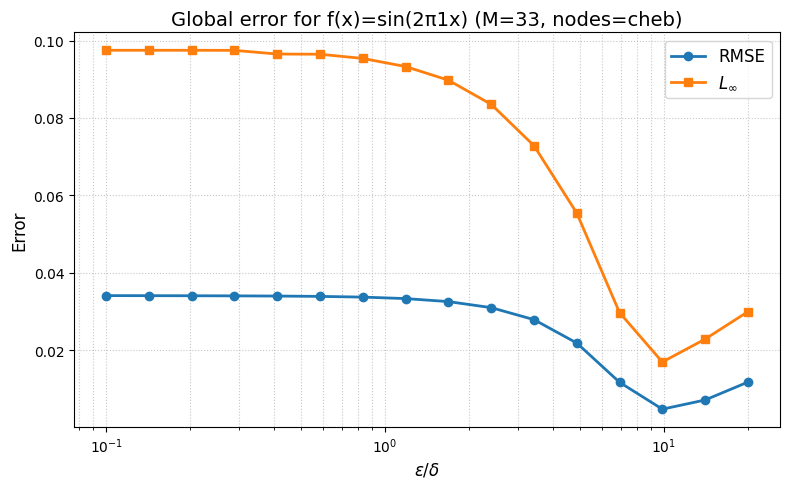

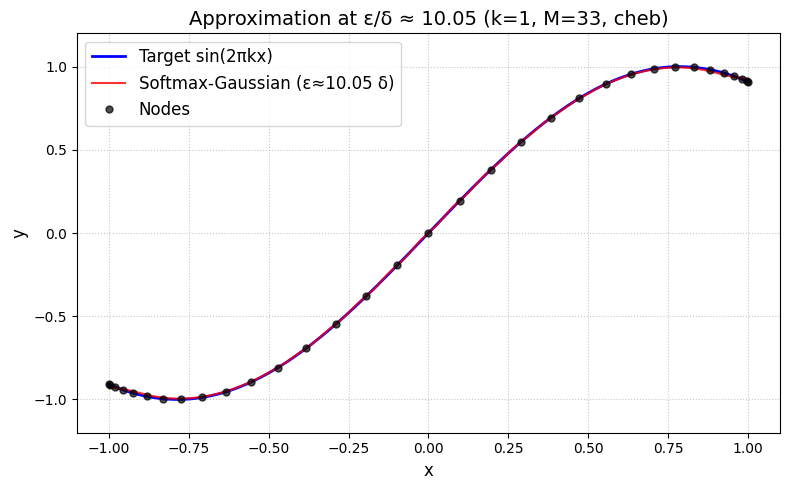

In [28]:
# Example: M=33 Chebyshev-Lobatto nodes, k=3
result_dict = run_demo(M=33, k=1, node_type="cheb", c_min=0.1, c_max=20.0, n_c=16)

In [29]:
# Training functions
def loss_fn(model: FixedGaussianSoftmax, x: jnp.ndarray, y: jnp.ndarray):
    y_hat = model(x)
    return jnp.mean((y_hat - y) ** 2)

def rel_l2_error(model, x_eval, y_eval):
    y_hat = model(x_eval)
    return jnp.linalg.norm(y_hat - y_eval) / jnp.linalg.norm(y_eval)

@nnx.jit
def train_step(model: FixedGaussianSoftmax, optimizer: nnx.Optimizer, x: jnp.ndarray, y: jnp.ndarray):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer = optimizer.update(model, grads)
    return loss

In [30]:
# =============== ε sweep for initialization ===============
def sweep_best_eps(
    xs: jnp.ndarray,
    ys: jnp.ndarray,
    a0: jnp.ndarray,
    x_eval: jnp.ndarray,
    y_eval: jnp.ndarray,
    cs: jnp.ndarray,   # ε = c * δ
):
    delta = min_separation(xs)
    eps_list = cs * delta
    def rmse_for_eps(eps):
        mdl = FixedGaussianSoftmax(
            xs, ys, epsilon=eps, a=a0
        )
        return loss_fn(mdl, x_eval, y_eval)
    rmse_vals = jax.vmap(rmse_for_eps)(eps_list)
    i_best = int(jnp.argmin(rmse_vals))
    return float(eps_list[i_best]), float(rmse_vals[i_best])


In [31]:
def run_experiment_broyden(
    M: int = 33,
    k: int = 3,
    node_type: str = "cheb",          # "cheb" or "uniform"
    # ε sweep
    c_min: float = 0.1, c_max: float = 20.0, n_c: int = 16,
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    softmax_first: bool = False,
    gauss_init: bool = True,
    rng_seed: float = 0,

):
    
    # nodes
    xs_cheb = cheb_lobatto_nodes(M) if node_type == "cheb" else uniform_nodes(M)
    ys_cheb = f_sin(xs_cheb, k)
    # magnitudes |a_j| for logits
    a0 = jnp.abs(cheb2_weights(M)) if node_type == "cheb" else jnp.ones((M,), dtype=DTYPE)

    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE)
    y_train = f_sin(x_train, k)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # ε sweep
    cs = jnp.geomspace(DTYPE(c_min), DTYPE(c_max), n_c)
    eps_star, rmse0 = sweep_best_eps(xs_cheb, ys_cheb, a0, x_train, y_train, cs)
    print(f"[init] best ε ≈ {eps_star:.4g} (RMSE={rmse0:.3e})")

    # init model with ε*
    model = TwoSoftmaxDiff(xs_cheb, ys_cheb, eps_f=eps_star, eps_g=eps_star, a_mag_f=a0, a_mag_g=a0, softmax_first=softmax_first, rng_seed=rng_seed, gauss_init=gauss_init)

    init_graphdef, init_state = nnx.split(model)
    init_model = nnx.merge(init_graphdef, init_state)

    # Create the optimizer pipeline
    # Build an (f,g) oracle that accepts a PARAMS-like pytree.
    # It reconstructs a temporary model using a static GraphDef.
    def make_fg_oracle(graphdef, base_state):
        """Oracle f(params, x, y) that rebuilds the model and stamps in `params` arrays."""
        base_state_pure = nnx.freeze(nnx.pure(base_state))  # pure arrays FlatState

        def f(params, x, y):
            # 1) reconstruct Node from the static graph + base state
            node = nnx.merge(graphdef, base_state_pure)
            # 2) stamp the param arrays into the live Node (structure must match nnx.Param tree)
            nnx.update(node, params)
            # 3) compute loss
            return loss_fn(node, x, y)

        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)

    # Wrap with the NNX optimizer (wrt=nnx.Param is required in 0.11)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}

    # Build the oracle once from a static graphdef
    graphdef, base_state = nnx.split(model)                 # base_state is the full FlatState (Params + Variables)
    base_state = nnx.freeze(nnx.pure(base_state))           # make it a pure arrays pytree for JIT-friendliness
    fg_oracle = make_fg_oracle(graphdef, base_state)

    @nnx.jit
    def train_step_b(model, opt, x, y):
        # grads w.r.t. model Params
        def cur_loss(m): return loss_fn(m, x, y)
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        opt.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, loss_args=(x, y))
        return f_k

    # training loop
    pbar = tqdm(range(steps), desc="training")
    print("Initial eval rel L2:", rel_l2_error(model, x_eval, y_eval))
    for i in pbar:
        loss = train_step_b(model, optim, x_train, y_train)
        if i % 10 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model, init_model

In [59]:
k = 16
model, init_model = run_experiment_broyden(M=64, k=k, node_type="cheb", c_min=0.1, c_max=20.0, n_c=16,
                       steps=20000, n_train=400, n_eval=20000, softmax_first=False, gauss_init=True, rng_seed = 1)

[init] best ε ≈ 0.01746 (RMSE=2.017e-02)


training:   0%|          | 0/20000 [00:00<?, ?it/s]

Initial eval rel L2: 1.0


step 6390, train loss=1.055e-12, eval rel L2=8.227e-05:  32%|███▏      | 6400/20000 [00:11<00:24, 545.86it/s]


KeyboardInterrupt: 

In [16]:
model

TwoSoftmaxDiff( # Param: 231 (1.8 KB)
  f=FixedGaussianSoftmax( # Param: 99 (792 B)
    W=Param( # 33 (264 B)
      value=Array(shape=(33,), dtype=dtype('float64'))
    ),
    b=Param( # 33 (264 B)
      value=Array(shape=(33,), dtype=dtype('float64'))
    ),
    y=Param( # 33 (264 B)
      value=Array(shape=(33,), dtype=dtype('float64'))
    )
  ),
  g=FixedGaussianSoftmax( # Param: 99 (792 B)
    W=Param( # 33 (264 B)
      value=Array(shape=(33,), dtype=dtype('float64'))
    ),
    b=Param( # 33 (264 B)
      value=Array(shape=(33,), dtype=dtype('float64'))
    ),
    y=Param( # 33 (264 B)
      value=Array(shape=(33,), dtype=dtype('float64'))
    )
  ),
  softmax_first=False,
  xs=Array(shape=(33,), dtype=dtype('float64')),
  ys=Param( # 33 (264 B)
    value=Array(shape=(33,), dtype=dtype('float64'))
  )
)

NameError: name 'model' is not defined

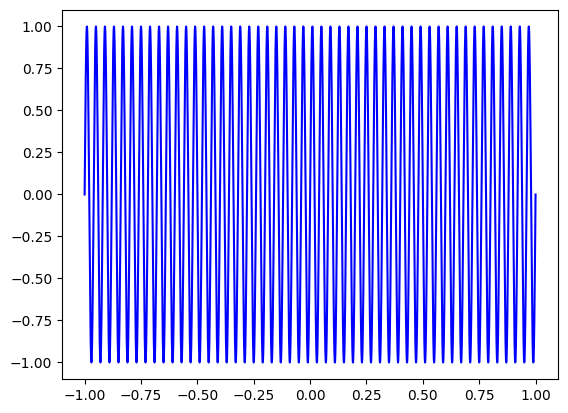

In [26]:
x_eval = jnp.linspace(-1.0, 1.0, 20000, dtype=DTYPE)
y_eval = f_sin(x_eval, k)
plt.plot(x_eval, y_eval, label='target', color='blue')
plt.plot(x_eval, model(x_eval), label='trained', color='red', alpha=0.7)
#plt.plot(x_eval, init_model(x_eval), label='init', color='green', alpha=0.7)
plt.legend()
plt.show()

In [27]:
plt.plot(x_eval, model(x_eval) - y_eval, label='trained error', color='red', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Error')
plt.title('Error after training')
plt.legend()
plt.show()

NameError: name 'model' is not defined

In [28]:
def nnx_compatible(tx: optax.GradientTransformation) -> optax.GradientTransformation:
    def init_fn(params):
        # strip NNX Variables -> pure arrays
        return tx.init(nnx.pure(params))
    def update_fn(updates, state, params=None, **kwargs):
        # grads/updates & params may be Variable pytrees in NNX
        updates = nnx.pure(updates)
        if params is not None:
            params = nnx.pure(params)
        return tx.update(updates, state, params=params, **kwargs)
    return optax.GradientTransformation(init_fn, update_fn)


def run_experiment(
    M: int = 33,
    k: int = 3,
    node_type: str = "cheb",          # "cheb" or "uniform"
    # ε sweep
    c_min: float = 0.1, c_max: float = 20.0, n_c: int = 16,
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    lr: float = 1e-2,
    softmax_first: bool = False,
    gauss_init: bool = True,
    rng: nnx.Rngs = nnx.Rngs(0),

):
    
    # nodes
    xs_cheb = cheb_lobatto_nodes(M) if node_type == "cheb" else uniform_nodes(M)
    ys_cheb = f_sin(xs_cheb, k)
    # magnitudes |a_j| for logits
    a0 = jnp.abs(cheb2_weights(M)) if node_type == "cheb" else jnp.ones((M,), dtype=DTYPE)

    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE)
    y_train = f_sin(x_train, k)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # ε sweep
    cs = jnp.geomspace(DTYPE(c_min), DTYPE(c_max), n_c)
    eps_star, rmse0 = sweep_best_eps(xs_cheb, ys_cheb, a0, x_train, y_train, cs)
    print(f"[init] best ε ≈ {eps_star:.4g} (RMSE={rmse0:.3e})")

    # init model with ε*
    model = TwoSoftmaxDiff(xs_cheb, ys_cheb, eps_f=eps_star, eps_g=eps_star, a_mag_f=a0, a_mag_g=a0, softmax_first=softmax_first, rngs=rng, gauss_init=gauss_init)
    #optim = nnx.Optimizer(model, optax.contrib.muon(learning_rate=lr), wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}
    #optim = nnx.Optimizer(model, optax.adam(learning_rate=lr), wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}
    #optim = nnx.Optimizer(model, optax.sgd(learning_rate=lr), wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}
    # --- in your run_experiment() just replace the failing line with:
    tx = nnx_compatible(optax.contrib.muon(learning_rate=lr))
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)

    # training loop
    pbar = tqdm(range(steps), desc="training")
    for i in pbar:
        loss = train_step(model, optim, x_train, y_train)
        if i % 1000 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model


In [29]:
model_muon = run_experiment(M=33, k=1, node_type="cheb", c_min=0.1, c_max=20.0, n_c=16,
                       steps=100000, n_train=2049, n_eval=20000, softmax_first=False, gauss_init=True, lr=1e-3)

[init] best ε ≈ 0.03338 (RMSE=1.537e-03)


step 14000, train loss=2.252e-05, eval rel L2=6.711e-03:  15%|█▍        | 14681/100000 [00:08<00:51, 1655.67it/s]


KeyboardInterrupt: 